# 03 - Local Distribution Analysis

**Key Statistical Discovery notebook.** Computes the 32x32 local beta-map
across the training set, tests whether beta varies spatially (ANOVA), and
correlates it with structural features (edge density, local variance,
entropy). This is the evidence that justifies the LDMH module in Notebook 04.

Run this on the FULL training set (or as large a subset as time allows) --
the earlier smoke-test used only 60 pairs; this version defaults to using
everything found.

In [2]:
%pip install scipy

^C
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import sys, os
sys.path.insert(0, "..") 

import numpy as np
import pandas as pd
from scipy import stats, ndimage
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from pathlib import Path
from utils.data import match_pairs, load_npy, downsample

np.random.seed(42)


In [ ]:
PROJECT_ROOT = Path("..").resolve()

TRAIN_GT_DIR = PROJECT_ROOT / "train" / "train" / "GT"
TRAIN_NOISY_DIR = PROJECT_ROOT / "train" / "train" / "NoisyLR"

PATCH_SIZE = 32
N_IMAGES = None

In [3]:
pairs = match_pairs(TRAIN_GT_DIR, TRAIN_NOISY_DIR)
if N_IMAGES:
    pairs = pairs[:N_IMAGES]
print(f"Using {len(pairs)} matched pairs.")


Using 3200 matched pairs.


In [4]:
def fit_patch_beta(residual_patch, min_std=1e-4):
    flat = residual_patch.flatten()
    if flat.std() < min_std:
        return np.nan, np.nan
    try:
        beta, loc, scale = stats.gennorm.fit(flat, floc=0.0)
        beta = np.clip(beta, 0.2, 4.0)
        return beta, scale
    except Exception:
        return np.nan, np.nan

def edge_density(gt_patch):
    gx = ndimage.sobel(gt_patch, axis=0)
    gy = ndimage.sobel(gt_patch, axis=1)
    return np.mean(np.sqrt(gx**2 + gy**2))

def local_variance(gt_patch):
    return np.var(gt_patch)

def local_entropy(gt_patch, bins=16):
    hist, _ = np.histogram(gt_patch, bins=bins, range=(0, 1), density=True)
    hist = hist[hist > 0]
    p = hist / hist.sum()
    return -np.sum(p * np.log2(p))


In [5]:
records = []
beta_maps_per_image = []
example_data = None

for img_idx, (gt_path, noisy_path) in enumerate(pairs):
    gt_img = load_npy(gt_path)
    noisy_img = load_npy(noisy_path)
    gt_ds = downsample(gt_img, noisy_img.shape[:2])
    residual = noisy_img - gt_ds

    H, W = noisy_img.shape
    n_rows, n_cols = H // PATCH_SIZE, W // PATCH_SIZE
    beta_map = np.full((n_rows, n_cols), np.nan)

    for i in range(n_rows):
        for j in range(n_cols):
            r0, c0 = i * PATCH_SIZE, j * PATCH_SIZE
            resid_patch = residual[r0:r0+PATCH_SIZE, c0:c0+PATCH_SIZE]
            gt_patch = gt_ds[r0:r0+PATCH_SIZE, c0:c0+PATCH_SIZE]

            beta, scale = fit_patch_beta(resid_patch)
            beta_map[i, j] = beta

            if not np.isnan(beta):
                records.append({
                    "beta": beta, "scale": scale,
                    "edge_density": edge_density(gt_patch),
                    "local_var": local_variance(gt_patch),
                    "entropy": local_entropy(gt_patch),
                    "image_idx": img_idx,
                })

    beta_maps_per_image.append(beta_map)
    if img_idx == 0:
        example_data = (gt_ds, noisy_img, residual, beta_map)

    if (img_idx + 1) % 50 == 0:
        print(f"  processed {img_idx+1}/{len(pairs)} images")

df = pd.DataFrame(records)
print(f"\nTotal patches with valid beta fit: {len(df)}")
df.to_csv("../results/local_beta_records.csv", index=False)
print("Saved: ../results/local_beta_records.csv")


  processed 50/3200 images
  processed 100/3200 images
  processed 150/3200 images
  processed 200/3200 images
  processed 250/3200 images
  processed 300/3200 images
  processed 350/3200 images
  processed 400/3200 images
  processed 450/3200 images
  processed 500/3200 images
  processed 550/3200 images
  processed 600/3200 images
  processed 650/3200 images
  processed 700/3200 images
  processed 750/3200 images
  processed 800/3200 images
  processed 850/3200 images
  processed 900/3200 images
  processed 950/3200 images
  processed 1000/3200 images
  processed 1050/3200 images
  processed 1100/3200 images
  processed 1150/3200 images
  processed 1200/3200 images
  processed 1250/3200 images
  processed 1300/3200 images
  processed 1350/3200 images
  processed 1400/3200 images
  processed 1450/3200 images
  processed 1500/3200 images
  processed 1550/3200 images
  processed 1600/3200 images
  processed 1650/3200 images
  processed 1700/3200 images
  processed 1750/3200 images
  pro

In [6]:
import os
print(os.getcwd())

c:\Users\Owner\OneDrive\Desktop\Golu Kumar\Semi conductor image paper\notebooks


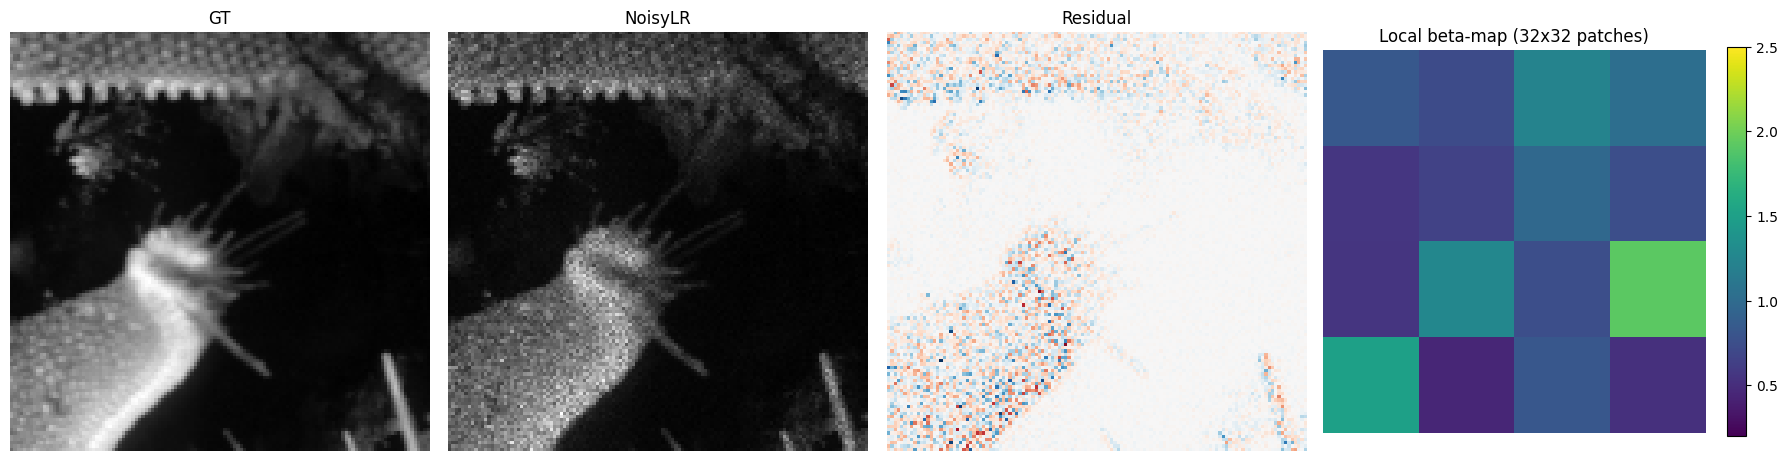

In [7]:
gt_ds, noisy_img, residual, beta_map = example_data

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
axes[0].imshow(gt_ds, cmap="gray"); axes[0].set_title("GT"); axes[0].axis("off")
axes[1].imshow(noisy_img, cmap="gray"); axes[1].set_title("NoisyLR"); axes[1].axis("off")
axes[2].imshow(residual, cmap="RdBu", vmin=-0.4, vmax=0.4); axes[2].set_title("Residual"); axes[2].axis("off")
im = axes[3].imshow(beta_map, cmap="viridis", vmin=0.2, vmax=2.5)
axes[3].set_title(f"Local beta-map ({PATCH_SIZE}x{PATCH_SIZE} patches)")
axes[3].axis("off")
plt.colorbar(im, ax=axes[3], fraction=0.046)
plt.tight_layout()
plt.savefig("../results/03_example_beta_map.png", dpi=150)
plt.show()


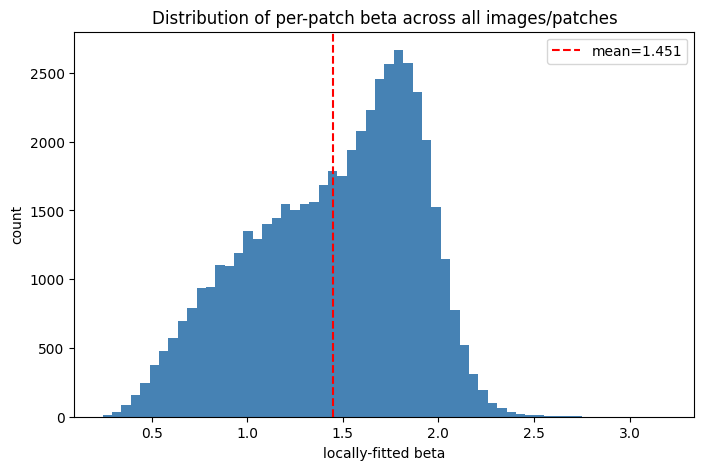

Global patch-level beta: mean=1.451, std=0.428

ANOVA across images: F=18.06, p=0.00e+00


In [8]:
plt.figure(figsize=(8,5))
plt.hist(df["beta"], bins=60, color="steelblue")
plt.axvline(df["beta"].mean(), color="red", linestyle="--", label=f"mean={df['beta'].mean():.3f}")
plt.xlabel("locally-fitted beta"); plt.ylabel("count")
plt.title("Distribution of per-patch beta across all images/patches")
plt.legend()
plt.savefig("../results/03_beta_histogram.png", dpi=150)
plt.show()

print(f"Global patch-level beta: mean={df['beta'].mean():.3f}, std={df['beta'].std():.3f}")

groups = [g["beta"].values for _, g in df.groupby("image_idx") if len(g) > 1]
f_stat, p_val = stats.f_oneway(*groups)
print(f"\nANOVA across images: F={f_stat:.2f}, p={p_val:.2e}")


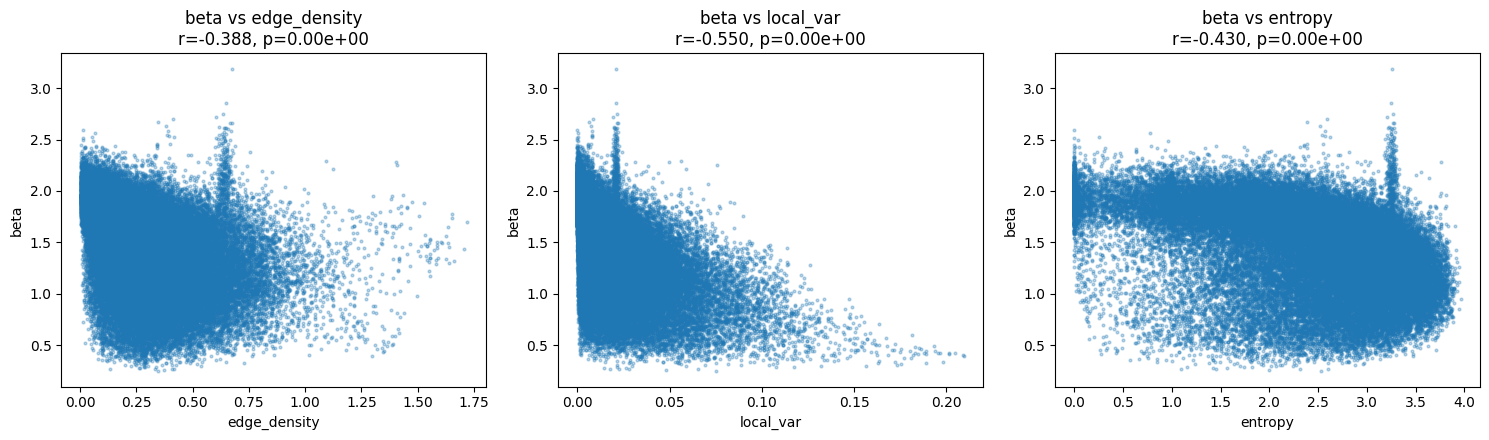

beta vs edge_density   : r=-0.388  p=0.00e+00
beta vs local_var      : r=-0.550  p=0.00e+00
beta vs entropy        : r=-0.430  p=0.00e+00


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15,4.5))
feats = ["edge_density", "local_var", "entropy"]
for ax, feat in zip(axes, feats):
    r, p = stats.pearsonr(df[feat], df["beta"])
    ax.scatter(df[feat], df["beta"], s=4, alpha=0.3)
    ax.set_xlabel(feat); ax.set_ylabel("beta")
    ax.set_title(f"beta vs {feat}\nr={r:.3f}, p={p:.2e}")
plt.tight_layout()
plt.savefig("../results/03_correlations.png", dpi=150)
plt.show()

for feat in feats:
    r, p = stats.pearsonr(df[feat], df["beta"])
    print(f"beta vs {feat:15s}: r={r:+.3f}  p={p:.2e}")
